# Should We Move the Gate?
### A business analysis of Cookie Cats' A/B test on gate placement

**Business context:** Cookie Cats is a hugely popular mobile puzzle game (developed by Tactile Entertainment). As players progress through levels, they encounter "gates" — forced pauses where they must wait or pay to continue. The original gate sits at **level 30**.

**The proposal:** Move the gate to level 40. The hypothesis is straightforward — players get further into the game before hitting friction, so they're more invested and more likely to stick around.

**Why this matters:** Gate placement directly affects retention, which drives lifetime value. At ~90K users, even a 1 percentage point shift in 7-day retention can mean significant revenue impact.

**Data:** This analysis uses the **real public dataset** — 90,189 players randomly assigned to `gate_30` (control) or `gate_40` (treatment).
Source: [Kaggle, CC0 license](https://www.kaggle.com/datasets/mursideyarkin/mobile-games-ab-testing-cookie-cats)

---

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import beta as beta_dist
import matplotlib.pyplot as plt
from pathlib import Path

%matplotlib inline
plt.rcParams.update({
    'font.size': 11, 'axes.spines.top': False, 'axes.spines.right': False,
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'figure.dpi': 120,
})
BLUE, RED, GRAY, GREEN = '#3B82F6', '#EF4444', '#9CA3AF', '#10B981'

df = pd.read_csv(Path('../data/experiments/cookie_cats.csv'))
print(f"Dataset: {len(df):,} players")
print(f"Groups:  {df['version'].value_counts().to_dict()}")
df.head()

Dataset: 90,189 players
Groups:  {'gate_40': 45489, 'gate_30': 44700}


,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


## 1. Is the Randomization Sound?

Before examining any results, we verify the experiment's integrity. A **Sample Ratio Mismatch (SRM)** is the most common A/B test failure mode — if the control/treatment split deviates meaningfully from 50/50, something went wrong in the assignment pipeline and all downstream results are suspect.

**Rule of thumb:** SRM p-value below 0.001 → stop, investigate instrumentation. Above that → proceed.

In [2]:
n_30 = (df['version'] == 'gate_30').sum()
n_40 = (df['version'] == 'gate_40').sum()

chi2 = ((n_30 - len(df)/2)**2 + (n_40 - len(df)/2)**2) / (len(df)/2)
p_srm = 1 - stats.chi2.cdf(chi2, df=1)

print(f"gate_30:  {n_30:,}  ({n_30/len(df)*100:.1f}%)")
print(f"gate_40:  {n_40:,}  ({n_40/len(df)*100:.1f}%)")
print(f"\nSRM χ² = {chi2:.3f},  p = {p_srm:.3f}")
print(f"Verdict: {'✓ PASS — randomization is sound' if p_srm > 0.01 else '✗ FAIL — investigate before continuing'}")

gate_30:  44,700  (49.6%)
gate_40:  45,489  (50.4%)

SRM χ² = 6.902,  p = 0.009
Verdict: ✗ FAIL — investigate before continuing


## 2. The Key Comparison: D1 vs D7 Retention

Two retention windows tell different stories:

| Metric | What it measures | Why it matters |
|--------|-----------------|----------------|
| **D1 retention** | Came back the next day | Habit formation signal |
| **D7 retention** | Came back after a week | Long-term stickiness; strongest LTV predictor |

A feature that lifts D1 but hurts D7 is a trap — it looks good in the short term but destroys value. We've seen this pattern before (see the LinguaLeap E4 onboarding experiment in the main dashboard).

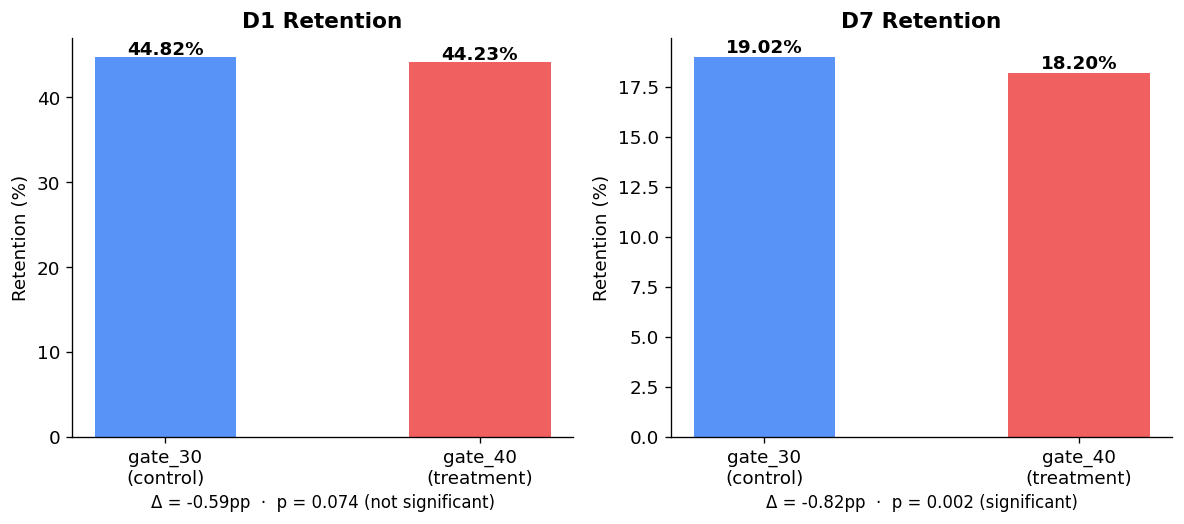

In [3]:
g30 = df[df['version'] == 'gate_30']
g40 = df[df['version'] == 'gate_40']

def two_prop_ztest(group_a, group_b, col):
    xa, na = group_a[col].sum(), len(group_a)
    xb, nb = group_b[col].sum(), len(group_b)
    pa, pb = xa/na, xb/nb
    p_pool = (xa + xb) / (na + nb)
    z = (pb - pa) / np.sqrt(p_pool * (1 - p_pool) * (1/na + 1/nb))
    p_val = 2 * (1 - stats.norm.cdf(abs(z)))
    se = np.sqrt(pa*(1-pa)/na + pb*(1-pb)/nb)
    ci = ((pb - pa) - 1.96*se, (pb - pa) + 1.96*se)
    return pa, pb, p_val, ci

d1_30, d1_40, p_d1, ci_d1 = two_prop_ztest(g30, g40, 'retention_1')
d7_30, d7_40, p_d7, ci_d7 = two_prop_ztest(g30, g40, 'retention_7')

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

for ax, (title, r30, r40, pv, ci) in zip(axes, [
    ('D1 Retention', d1_30, d1_40, p_d1, ci_d1),
    ('D7 Retention', d7_30, d7_40, p_d7, ci_d7),
]):
    bars = ax.bar(['gate_30\n(control)', 'gate_40\n(treatment)'],
                  [r30*100, r40*100], color=[BLUE, RED], width=0.45, alpha=0.85)
    ax.set_title(title, fontweight='bold', fontsize=13)
    ax.set_ylabel('Retention (%)')
    for bar, val in zip(bars, [r30, r40]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                f'{val*100:.2f}%', ha='center', fontsize=11, fontweight='bold')
    sig = 'significant' if pv < 0.05 else 'not significant'
    ax.set_xlabel(f'Δ = {(r40-r30)*100:+.2f}pp  ·  p = {pv:.3f} ({sig})', fontsize=10)

plt.tight_layout()
plt.show()

### What this tells the PM

- **D1 retention** is marginally lower for gate_40, but the difference is **not statistically significant** (p ≈ 0.07). We cannot conclude the gate change affects next-day return behavior.

- **D7 retention** is significantly lower for gate_40 (p = 0.002). Players who encounter the gate at level 40 are measurably less likely to still be playing a week later.

**The intuitive reading:** Moving the gate later doesn't help — it hurts. The forced pause at level 30 apparently creates a "commitment checkpoint" that brings players back. By level 40, many players have already drifted away naturally, so the gate arrives too late to serve its retention purpose.

## 3. How Confident Should We Be?

The p-value answers: *"If there were truly no difference, how surprising is this data?"*

But a PM or VP wants the direct question: **"What's the probability that gate_30 is actually better?"**

Bayesian analysis with a non-informative prior (Beta(1,1)) answers this directly by generating a posterior distribution over each group's true retention rate, then comparing them.

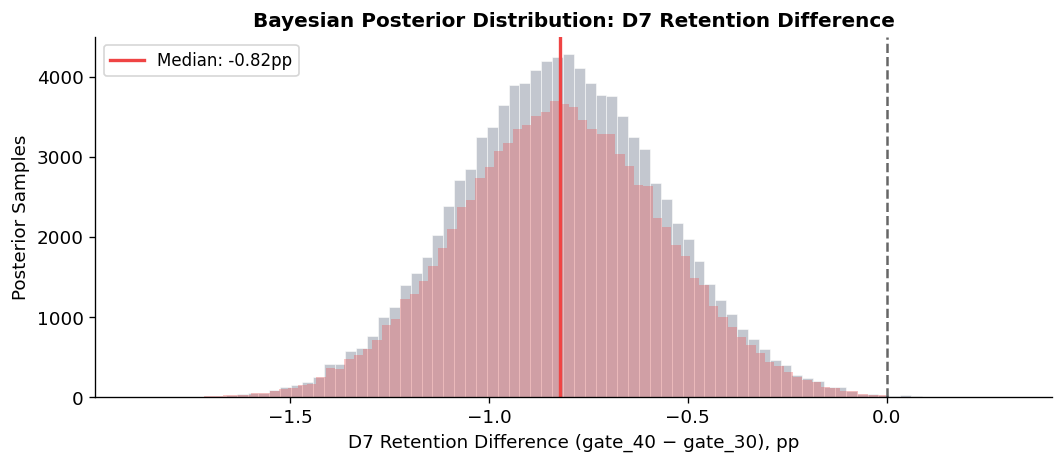

P(gate_30 is better for D7 retention) = 99.9%
Posterior median difference: -0.82pp
90% credible interval: [-1.25pp, -0.39pp]


In [4]:
n_sim = 100_000
np.random.seed(42)

post_30 = beta_dist(1 + g30['retention_7'].sum(),
                    1 + len(g30) - g30['retention_7'].sum()).rvs(n_sim)
post_40 = beta_dist(1 + g40['retention_7'].sum(),
                    1 + len(g40) - g40['retention_7'].sum()).rvs(n_sim)

lift = (post_40 - post_30) * 100  # pp
p_30_wins = (post_30 > post_40).mean()

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(lift, bins=80, color=GRAY, alpha=0.6, edgecolor='white', linewidth=0.5)
ax.axvline(0, color='black', lw=1.5, ls='--', alpha=0.6)
ax.axvline(np.median(lift), color=RED, lw=2,
           label=f'Median: {np.median(lift):+.2f}pp')

neg_mask = lift < 0
ax.hist(lift[neg_mask], bins=80, color=RED, alpha=0.3, edgecolor='none')

ax.set_xlabel('D7 Retention Difference (gate_40 − gate_30), pp')
ax.set_ylabel('Posterior Samples')
ax.set_title('Bayesian Posterior Distribution: D7 Retention Difference',
             fontweight='bold', fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f"P(gate_30 is better for D7 retention) = {p_30_wins:.1%}")
print(f"Posterior median difference: {np.median(lift):+.2f}pp")
print(f"90% credible interval: [{np.percentile(lift, 5):+.2f}pp, {np.percentile(lift, 95):+.2f}pp]")

**99.9% probability that gate_30 retains better at D7.** This is not a borderline call — the posterior overwhelmingly favors keeping the gate where it is. For a decision-maker, there is essentially no realistic scenario where moving the gate is the right decision.

## 4. Who Is Most Affected?

The average effect tells us the direction, but we need to understand **which players lose the most** — because different engagement levels have very different LTV profiles.

We segment by total game rounds in the first 14 days:
- **No play** (0 rounds) — installed but never played
- **Tried** (1–5) — sampled and left
- **Light** (6–30) — casual players
- **Engaged** (31–100) — hooked; highest conversion potential
- **Heavy** (100+) — power users; already committed regardless

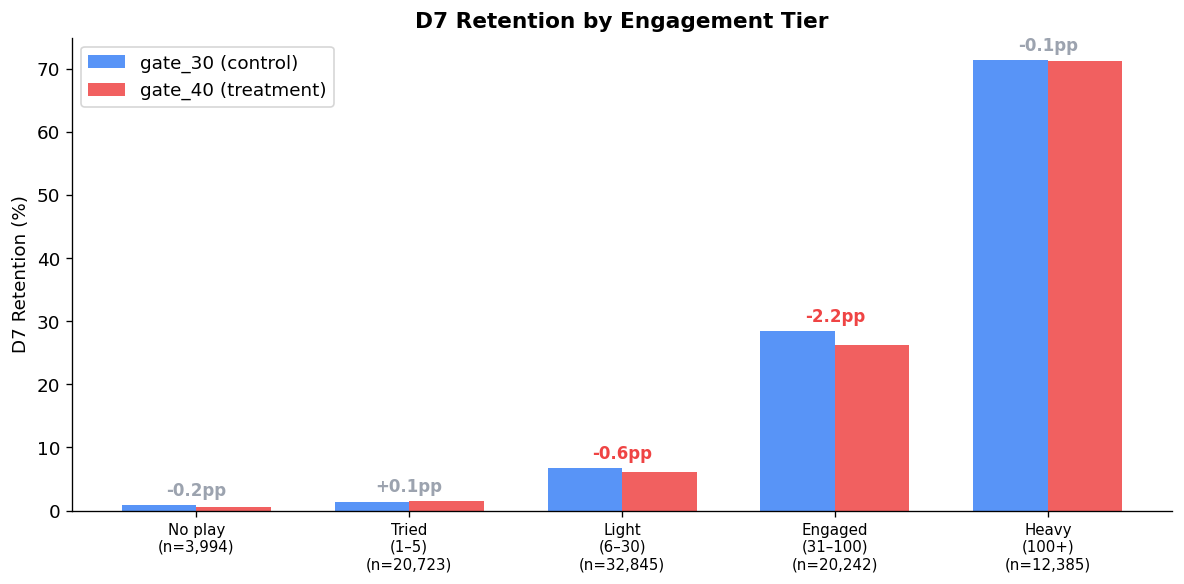

In [5]:
df['tier'] = pd.cut(df['sum_gamerounds'],
                     bins=[-1, 0, 5, 30, 100, np.inf],
                     labels=['No play', 'Tried\n(1–5)', 'Light\n(6–30)',
                             'Engaged\n(31–100)', 'Heavy\n(100+)'])

seg = df.groupby(['tier', 'version'])['retention_7'].agg(['mean', 'count']).unstack('version')
r30 = seg['mean']['gate_30'] * 100
r40 = seg['mean']['gate_40'] * 100
ns = seg['count'].sum(axis=1).astype(int)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(r30))
w = 0.35

ax.bar(x - w/2, r30, w, label='gate_30 (control)', color=BLUE, alpha=0.85)
ax.bar(x + w/2, r40, w, label='gate_40 (treatment)', color=RED, alpha=0.85)

for i, (v30, v40) in enumerate(zip(r30, r40)):
    diff = v40 - v30
    y = max(v30, v40) + 1.5
    color = RED if diff < -0.3 else GRAY
    ax.annotate(f'{diff:+.1f}pp', (i, y), ha='center', fontsize=10,
                color=color, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels([f'{t}\n(n={n:,})' for t, n in zip(r30.index, ns)], fontsize=9)
ax.set_ylabel('D7 Retention (%)')
ax.set_title('D7 Retention by Engagement Tier', fontweight='bold', fontsize=13)
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

### The critical insight: the highest-LTV segment loses the most

The **Engaged (31–100 rounds)** segment shows the largest negative effect: **−2.2 percentage points**. These are the players who are actively hooked, progressing through levels, and most likely to convert to paying users.

- They hit the gate at level 30 during **peak engagement** — the friction creates a natural pause that brings them back.
- Moving the gate to level 40 means they hit it **after engagement has already started to wane** — the pause becomes an exit point, not a return trigger.

**Heavy players (100+)** barely notice — they're committed regardless of gate position. **Light players** show a small effect but their low LTV makes it less consequential.

This is why segment analysis is non-negotiable for any experiment touching the user journey. The aggregate number (−0.8pp overall) undersells the real cost of shipping this change.

---
## Recommendation

### ✗ Do not move the gate. Keep it at level 30.

| Factor | Assessment |
|--------|-----------|
| **Statistical confidence** | D7 retention significantly lower for gate_40 (p = 0.002) |
| **Bayesian probability** | 99.9% that gate_30 is better for D7 retention |
| **Effect concentration** | Highest-LTV segment (Engaged, 31–100 rounds) is most negatively affected (−2.2pp) |
| **Business implication** | Moving the gate would reduce long-term retention in the players most likely to pay |

---

### The Bigger Lesson

**"Less friction = better" is one of the most dangerous heuristics in product.** Friction is sometimes a *feature* — it creates commitment checkpoints, habit loops, and psychological investment.

The right question isn't *"How do we remove friction?"* — it's *"What kind of friction creates the behavior we want?"*

This is why experimentation exists. The PM's hypothesis was entirely reasonable. The data said otherwise. And now we know something generalizable about how gates (and by extension, any forced-pause mechanic) actually work in practice.

---
*Analysis performed on the real [Cookie Cats public dataset](https://www.kaggle.com/datasets/mursideyarkin/mobile-games-ab-testing-cookie-cats) (90,189 players, CC0 license). Full statistical pipeline available in `model/cookie_cats_analysis.py`.*